# Motion Blur Analysis

Quantifies the effect of translational motion blur on localisation precision and colour precision
using the elliptical S3M fitting pipeline (`FittingStrategy.ELLIPTICAL`).

**Motion model:** constant velocity in a random direction during a 100 ms frame exposure.
Per-frame displacement = velocity × 0.1 s.  Each frame gets an independent random direction.

**Structure**
1. PSF shape visualisation — Gaussian PSF at increasing motion blur displacement
2. Velocity sweep simulation — N velocities × 3 photon levels × 3 dyes
3. Analysis — localisation precision, colour precision, and PSF ellipticity vs velocity

In [1]:
import sys, os, glob, types
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

sys.path.append(str(Path(os.getcwd()).parent.parent))

from src import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from src.Multicolour_Simulation_Functions import (
    FittingStrategy, SimulationConfig, MultiC_Sim_Funcs,
)

IO    = IOFunctions.IO_Functions()
S_F   = SpectralFunctions.Spectral_Funcs()
M_F   = MaskFunctions.Mask_Functions()
sCMOS = sCMOSFunctions.sCMOS_Functions()
MSF   = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

In [2]:
# ── Camera calibration ────────────────────────────────────────────────────────
cal_folder = Path("../../Camera_Calibrations/Ximea_Camera/")
gain      = IO.read_tiff(str(cal_folder / "gain.tif"))
offset    = IO.read_tiff(str(cal_folder / "offset.tif"))
variance  = IO.read_tiff(str(cal_folder / "variance.tif"))
readnoise = float(np.median(IO.read_tiff(str(cal_folder / "readnoise.tif"))))
rqe       = IO.read_tiff(str(cal_folder / "rqe.tif"))

print(f"Camera calibration loaded — sensor: {gain.shape}, readnoise: {readnoise:.2f}")

Camera calibration loaded — sensor: (1544, 2064), readnoise: 2.34


In [3]:
# ── Spectral setup ────────────────────────────────────────────────────────────
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])   # (3, n_wl); convention B=0, G=1, R=2

dyes          = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters       = []
NA            = 1.49
pixel_size_nm = 69.0        # Ximea object-space pixel (nm)
image_dims    = 22          # 22 × 22 px
background_photons = 40.0
frame_exposure_ms  = 100.0  # fixed 100 ms frame exposure

smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg="image",
)

print(f"Wavelength grid: {wavelength[0]:.0f}–{wavelength[-1]:.0f} nm  ({len(wavelength)} pts)")

Wavelength grid: 400–999 nm  (600 pts)


In [4]:
# ── Save folder ───────────────────────────────────────────────────────────────
save_folder = Path("/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur")
save_folder.mkdir(parents=True, exist_ok=True)
print(f"Results → {save_folder}")

Results → /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur


## Figure 1: PSF shape under motion blur

Time-integrated Gaussian PSF at increasing displacement (velocity × 100 ms exposure).  
No noise, no camera effects — shows the pure effect of the motion blur kernel.

In [5]:
# ── Compute motion-blurred PSFs for visualisation ─────────────────────────────
# Use a fine pixel grid to resolve the Airy disk structure.
from src.simulation.multicolour import MultiC_Sim_Funcs_Refactored

pix_vis_nm  = 10.0          # 10 nm/px oversampling
psf_size_vis = 201          # 2.01 µm window
sigma_vis_nm = 120.0        # approximate Gaussian sigma for a 488 nm dye, NA 1.49

# Displacements to show: 0, 50, 100, 200, 400 nm (= 0, 500, 1000, 2000, 4000 nm/s × 100 ms)
displacements_nm = np.array([0, 100, 250, 500, 1000], dtype=float)
n_disp = len(displacements_nm)

# Build analytic Gaussian PSF callable on a (psf_size_vis × psf_size_vis) grid
_cx = psf_size_vis / 2.0
xx, yy = np.meshgrid(np.arange(psf_size_vis), np.arange(psf_size_vis), indexing="ij")
sigma_px = sigma_vis_nm / pix_vis_nm

def _gauss_fn(x0, y0, _n):
    g = np.exp(-((xx - x0)**2 + (yy - y0)**2) / (2 * sigma_px**2))
    return (g / g.sum()).astype(np.float32)

psf_vis_stack = []
np.random.seed(42)
for d_nm in displacements_nm:
    d_px = d_nm / pix_vis_nm
    if d_px == 0.0:
        psf_vis_stack.append(_gauss_fn(_cx, _cx, None))
    else:
        angle = np.random.uniform(0, 2 * np.pi)  # representative single angle
        psf_vis_stack.append(
            MultiC_Sim_Funcs_Refactored._apply_motion_blur(
                _gauss_fn, np.array([_cx]), np.array([_cx]), np.array([1]),
                d_px, angle, n_samples=51,
            )
        )

print(f"Computed {n_disp} PSF images  (pixel size {pix_vis_nm} nm, σ = {sigma_vis_nm} nm)")

Computed 5 PSF images  (pixel size 10.0 nm, σ = 120.0 nm)


/tmp/ipykernel_684405/3807301558.py:24: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05)
INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/psf_motion_blur_panels.svg


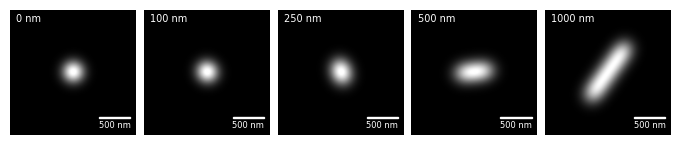

Figure 1 saved.


In [6]:
# ── Figure 1: motion-blurred PSF panels ──────────────────────────────────────
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_disp, height=6.69 / n_disp + 0.1)
fs = plotter.config.font_size

for i_d, (d_nm, psf) in enumerate(zip(displacements_nm, psf_vis_stack)):
    I_disp = psf / psf.max()
    plotter.image_plot(
        axs[i_d], I_disp,
        cmap="gray",
        vmin=np.percentile(I_disp, 1), vmax=np.percentile(I_disp, 99.9),
        scalebar=True, pixelsize=pix_vis_nm,
        scalebarsize=500.0, scalebarlabel="500 nm",
        scalebar_color="white", origin="lower",
        colorbar=False,
    )
    label = f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm"
    axs[i_d].text(
        0.05, 0.97, label,
        transform=axs[i_d].transAxes,
        fontsize=fs, color="white", va="top", ha="left",
        bbox=dict(boxstyle="square,pad=0.15", fc="none", ec="none"),
    )

fig.subplots_adjust(wspace=0.05)
plotter.save_or_show(fig, save_path=str(save_folder / "psf_motion_blur_panels.svg"), show=True)
print("Figure 1 saved.")

## Velocity Sweep Simulation

For each (dye, velocity), run `test_simulation_method` with `FittingStrategy.ELLIPTICAL`
across three photon levels.  The elliptical fitter recovers separate σ_x, σ_y, and θ per localisation,
so the blur-induced PSF elongation is captured directly rather than being averaged into a wider circular σ.

Velocities span 0–5000 nm/s → displacements 0–500 nm at 100 ms exposure
(0–7.2 pixels at 69 nm/px).

In [7]:
# ── Sweep parameters ─────────────────────────────────────────────────────────
velocities_nm_per_s = np.hstack([0, np.geomspace(25, 10000, 49)])
displacements_sweep_nm = velocities_nm_per_s * (frame_exposure_ms / 1000.0)

n_photon_space = np.geomspace(500, 20000, 100)
n_bootstrap    = 10000

print(f"Velocities (nm/s): {velocities_nm_per_s}")
print(f"Displacements (nm): {displacements_sweep_nm}")
print(f"\nSweep: {len(dyes)} dyes × {len(velocities_nm_per_s)} velocities")
print(f"Total simulation calls: {len(dyes) * len(velocities_nm_per_s)}")

Velocities (nm/s): [     0.             25.             28.32367431     32.08922105
     36.35538584     41.18872431     46.6646405      52.86856317
     59.89727858     67.86044041     76.88228051     87.10354693
     98.68369977    111.80339887    126.66732225    143.50735924
    162.58622816    184.20157493    208.69061662    236.43540225
    267.86877313    303.4811155     343.82801097    389.53890403
    441.32692192    500.            566.47348617    641.78442106
    727.10771672    823.77448622    933.29281005   1057.37126344
   1197.94557154   1357.2088083    1537.64561018   1742.07093857
   1973.67399544   2236.0679775    2533.34644503   2870.14718476
   3251.72456312   3684.03149864   4173.81233235   4728.70804502
   5357.37546263   6069.62231003   6876.56021934   7790.77808054
   8826.53843845  10000.        ]
Displacements (nm): [    0.             2.5            2.83236743     3.20892211     3.63553858
     4.11887243     4.66646405     5.28685632     5.98972786     6.7860

In [8]:
# ── Camera parameters dictionary ──────────────────────────────────────────────
def make_camera_params(image_dims):
    return {
        "gain":               np.full((image_dims, image_dims), np.median(gain)),
        "offset":             np.full((image_dims, image_dims), np.median(offset)),
        "variance":           np.full((image_dims, image_dims), np.median(variance)),
        "readnoise":          readnoise,
        "rqe":                np.full((image_dims, image_dims), np.median(rqe)),
        "masks":              M_F.get_masks(size_x=image_dims, size_y=image_dims),
        "pixel_QYs":          pixel_QYs,
        "pixel_order":        ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }

camera_params_dict = make_camera_params(image_dims)
print(f"Camera parameters ready — image size: {image_dims}×{image_dims} px")

Camera parameters ready — image size: 22×22 px


In [ ]:
# ── Run sweep ─────────────────────────────────────────────────────────────────
import time

n_total = len(dyes) * len(velocities_nm_per_s)
i_run   = 0
t_start = time.time()

for dye in dyes:
    for v_nm_s in velocities_nm_per_s:
        i_run += 1
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        config = SimulationConfig(
            n_bootstrap=n_bootstrap,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size_nm,
            save_raw_results=True,
            subtractx0y0=False,
            use_stochastic_photons=True,
            save_summary_csvs=True,
            verbose=False,
            motion_velocity_nm_per_s=float(v_nm_s),
            frame_exposure_ms=frame_exposure_ms,
        )

        disp_nm = v_nm_s * (frame_exposure_ms / 1000.0)
        print(
            f"[{i_run:3d}/{n_total}]  {dye}  v={v_nm_s:.0f} nm/s  "
            f"(displacement {disp_nm:.0f} nm)",
            end="  ", flush=True,
        )

        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=str(save_folder),
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.ELLIPTICAL,
            starting_flag=flag,
            config=config,
            overwrite=True,
        )

        elapsed = (time.time() - t_start) / 60.0
        rate    = i_run / elapsed if elapsed > 0 else 0
        eta     = (n_total - i_run) / rate if rate > 0 else 0
        print(f"done   ({elapsed:.1f} min elapsed, ETA {eta:.1f} min)")

print(f"\nSweep complete in {(time.time()-t_start)/60:.1f} min.")

[  1/150]  ATTO 488  v=0 nm/s  (displacement 0 nm)  

INFO:simulation.multicolour:Overwrite=True: Deleting existing results file: motionblur_v000000nms_LM_method_ATTO 488_rawresults.h5


INFO:simulation.multicolour:
Completed analysis of 100 photon flux values    Total time: 15.973 min
INFO:simulation.multicolour:Simulation completed for strategy elliptical


done   (16.0 min elapsed, ETA 2380.6 min)


## Analysis

Load the RMSE summary CSVs and the raw HDF5 results.  
The raw results contain `theta` (fitted blur angle) and separate `s_x`, `s_y`,  
which directly quantify the blur-induced PSF ellipticity.

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors

# ── Build xarray DataArray: σ_xy + σ_colour from RMSE CSVs; ellipticity from raw HDF5 ──
# Dims: [dye, displacement_nm, n_photons, metric]
metrics = ["sigma_xy", "colour_dist", "ellipticity"]

da_motion = xr.DataArray(
    data=np.full(
        [len(dyes), len(velocities_nm_per_s), len(n_photon_space), len(metrics)],
        np.nan,
    ),
    coords={
        "dye":            dyes,
        "displacement_nm": displacements_sweep_nm,
        "n_photons":      n_photon_space,
        "metric":         metrics,
    },
    dims=["dye", "displacement_nm", "n_photons", "metric"],
)

missing = []
for i_dye, dye in enumerate(dyes):
    dye_str = dye.replace("/", "-")
    for i_v, v_nm_s in enumerate(velocities_nm_per_s):
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        # σ_xy and σ_colour from RMSE CSV
        pattern = str(save_folder / f"{flag}*{dye_str}*RMSE_mean*.csv")
        files = sorted(glob.glob(pattern))
        if not files:
            missing.append((dye, v_nm_s))
        else:
            df = pl.read_csv(files[0])
            for i_ph, row in enumerate(df.iter_rows(named=True)):
                da_motion[i_dye, i_v, i_ph, 0] = float(
                    np.sqrt((row["xc"] ** 2 + row["yc"] ** 2) / 2)
                )
                da_motion[i_dye, i_v, i_ph, 1] = float(row["colour_distance"])

        # Ellipticity from raw HDF5: σ_major / σ_minor per photon level
        h5_path = save_folder / f"{flag}LM_method_{dye_str}_rawresults.h5"
        if h5_path.exists():
            try:
                df_raw = pd.read_hdf(str(h5_path), key="data")
                for i_ph in range(len(n_photon_space)):
                    subset = df_raw[df_raw["photon_level"] == i_ph]
                    if len(subset) == 0:
                        continue
                    sx = subset["s_x"].dropna().to_numpy() * pixel_size_nm
                    sy = subset["s_y"].dropna().to_numpy() * pixel_size_nm
                    s_maj = np.maximum(sx, sy)
                    s_min = np.minimum(sx, sy)
                    with np.errstate(divide="ignore", invalid="ignore"):
                        ell = np.where(s_min > 0, s_maj / s_min, np.nan)
                    da_motion[i_dye, i_v, i_ph, 2] = float(np.nanmedian(ell))
            except Exception as e:
                print(f"  Could not load {h5_path.name}: {e}")

if missing:
    print(f"Missing RMSE files: {missing}")
da_motion.to_netcdf(str(save_folder / "motionblur_sweep.nc"))
print(f"DataArray shape: {da_motion.shape}  →  saved motionblur_sweep.nc")
print(f"σ_xy  range : {float(da_motion.sel(metric='sigma_xy').min()):.1f}–"
      f"{float(da_motion.sel(metric='sigma_xy').max()):.1f} nm")
print(f"ellipticity : {float(da_motion.sel(metric='ellipticity').min()):.3f}–"
      f"{float(da_motion.sel(metric='ellipticity').max()):.3f}")

In [ ]:
# ── Plotting helpers ──────────────────────────────────────────────────────────
dye_labels = {"ATTO 488": "ATTO 488", "ATTO 565": "ATTO 565", "ATTO 647N": "ATTO 647N"}
fs = plotter.config.font_size

In [ ]:
# ── Figure 2: localisation precision σ_xy — surface map ──────────────────────
# X = displacement (nm), Y = photon count (log), colour = σ_xy (nm, viridis).
# One panel per dye; shared colour scale across all three dyes.
metric     = "sigma_xy"
cbar_label = r"$\sigma_{xy}$ / nm"

data_m = da_motion.sel(metric=metric).values  # (n_dye, n_disp, n_ph)
vmin, vmax = float(np.nanmin(data_m)), float(np.nanmax(data_m))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
xlabels = np.array([0, 100, 200, 300, 500, 500, 750, 1000])

fig, axs = plt.subplots(nrows=1, ncols=len(dyes), figsize=(6.69, 2.5), squeeze=False)
for i_c, dye in enumerate(dyes):
    ax = axs[0, i_c]
    # da shape: (n_disp, n_photons); transpose → (n_photons, n_disp) for pcolormesh
    Z = da_motion.isel(dye=i_c).sel(metric=metric).values
    ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                  cmap="viridis", shading="auto", norm=norm)
    ax.set_yscale("log")
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.set_xticks(xlabels)
    ax.tick_params(labelsize=fs - 1)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
             ax=axs, label=cbar_label, shrink=0.85, aspect=20, pad=0.02)
#fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "localisation_precision_surface.svg"))

In [ ]:
# ── Figure 3: colour precision σ_colour — surface map ────────────────────────
metric     = "colour_dist"
cbar_label = r"$\sigma_{\mathrm{colour}}$ (a.u.)"

data_m = da_motion.sel(metric=metric).values
vmin, vmax = float(np.nanmin(data_m)), float(np.nanmax(data_m))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(nrows=1, ncols=len(dyes), figsize=(6.69, 2.5), squeeze=False)
for i_c, dye in enumerate(dyes):
    ax = axs[0, i_c]
    Z = da_motion.isel(dye=i_c).sel(metric=metric).values
    ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                  cmap="viridis", shading="auto", norm=norm)
    ax.set_yscale("log")
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
             ax=axs, label=cbar_label, shrink=0.85, aspect=20, pad=0.02)
plotter.save_or_show(fig, save_path=str(save_folder / "colour_precision_surface.svg"))

In [ ]:
# ── Figure 4: PSF ellipticity σ_major/σ_minor — surface map ──────────────────
# Floor at 1.0 (perfect circle); rises as motion blur elongates the PSF.
metric     = "ellipticity"
cbar_label = r"Ellipticity $\sigma_{\mathrm{maj}}/\sigma_{\mathrm{min}}$"

data_m = da_motion.sel(metric=metric).values
vmin = max(1.0, float(np.nanmin(data_m)))
vmax = float(np.nanmax(data_m))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(nrows=1, ncols=len(dyes), figsize=(6.69, 2.5), squeeze=False)
for i_c, dye in enumerate(dyes):
    ax = axs[0, i_c]
    Z = da_motion.isel(dye=i_c).sel(metric=metric).values
    ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                  cmap="viridis", shading="auto", norm=norm)
    ax.set_yscale("log")
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
             ax=axs, label=cbar_label, shrink=0.85, aspect=20, pad=0.02)
plotter.save_or_show(fig, save_path=str(save_folder / "psf_ellipticity_surface.svg"))

In [ ]:
# ── Figure 5: combined 3-metric × 3-dye summary surface ──────────────────────
# Rows: σ_xy, σ_colour, ellipticity.  Columns: dyes.
# Each row has its own normalisation so all three metrics are clearly visible.
metric_list = ["sigma_xy",             "colour_dist",                          "ellipticity"]
cbar_lbls   = [r"$\sigma_{xy}$ / nm", r"$\sigma_{\mathrm{colour}}$ (a.u.)",
               r"Ellipticity $\sigma_{\mathrm{maj}}/\sigma_{\mathrm{min}}$"]

fig, axs = plt.subplots(
    nrows=len(metric_list), ncols=len(dyes),
    figsize=(6.69, 2.5 * len(metric_list)),
    squeeze=False,
)
for i_m, (metric, cbar_lbl) in enumerate(zip(metric_list, cbar_lbls)):
    data_row = da_motion.sel(metric=metric).values  # (n_dye, n_disp, n_ph)
    vmin = max(1.0, float(np.nanmin(data_row))) if metric == "ellipticity" else float(np.nanmin(data_row))
    vmax = float(np.nanmax(data_row))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i_c, dye in enumerate(dyes):
        ax = axs[i_m, i_c]
        Z = da_motion.isel(dye=i_c).sel(metric=metric).values  # (n_disp, n_ph)
        ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                      cmap="viridis", shading="auto", norm=norm)
        ax.set_yscale("log")
        ax.set_xlabel("Displacement / nm", fontsize=fs)
        ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs - 1)
        if i_m == 0:
            ax.set_title(dye_labels[dye], fontsize=fs)
        ax.tick_params(labelsize=fs - 1)

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
        ax=axs[i_m, :].tolist(),
        label=cbar_lbl, shrink=0.85, aspect=20, pad=0.02,
    )

plotter.save_or_show(fig, save_path=str(save_folder / "combined_summary_surface.svg"))

## Bias Analysis

Bias = systematic offset of the **mean** fit from truth (distinct from precision/RMSE above).

- **Position bias** `bias_xy`: $\sqrt{(\bar\epsilon_x^2 + \bar\epsilon_y^2)/2}$ in nm, where $\bar\epsilon = \text{mean}(x_\text{fit} - x_0)$ across bootstraps.
- **Colour bias** `colour_bias`: Euclidean distance of the mean normalised fitted colour $\bar f_\text{fit} = \overline{A_\text{BGR}/\sum A}$ from the true BGR fraction $f_\text{true}$.

Both metrics use only valid localisations (positive $\sigma$, within image bounds).

In [ ]:
from scipy.spatial.distance import cdist

# ── Build bias DataArray from raw HDF5 + groundtruth/input_params CSVs ────────
# bias_xy     : sqrt((mean_ex^2 + mean_ey^2) / 2)  in nm
# colour_bias : ||mean(A_BGR / sum) − true_BGR||   (normalised fraction space)
metrics_bias = ["bias_xy", "colour_bias"]

da_motion_bias = xr.DataArray(
    data=np.full(
        [len(dyes), len(velocities_nm_per_s), len(n_photon_space), len(metrics_bias)],
        np.nan,
    ),
    coords={
        "dye":            dyes,
        "displacement_nm": displacements_sweep_nm,
        "n_photons":      n_photon_space,
        "metric":         metrics_bias,
    },
    dims=["dye", "displacement_nm", "n_photons", "metric"],
)

for i_dye, dye in enumerate(dyes):
    dye_str = dye.replace("/", "-")
    for i_v, v_nm_s in enumerate(velocities_nm_per_s):
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        gt_files = sorted(glob.glob(str(save_folder / f"{flag}*{dye_str}*groundtruth*.csv")))
        ip_files = sorted(glob.glob(str(save_folder / f"{flag}*{dye_str}*input_parameters*.csv")))
        h5_path  = save_folder / f"{flag}LM_method_{dye_str}_rawresults.h5"

        if not gt_files or not ip_files or not h5_path.exists():
            continue

        gt    = pd.read_csv(gt_files[0])
        gt_px = np.vstack([gt["x0"].to_numpy() / pixel_size_nm,
                           gt["y0"].to_numpy() / pixel_size_nm]).T  # (n_bootstrap, 2) px

        dye_BGR = pd.read_csv(ip_files[0]).to_numpy()[0][-3:]
        colour_true = (dye_BGR / dye_BGR.sum()).reshape(1, 3)

        df_raw = pd.read_hdf(str(h5_path), key="data")

        for i_ph in range(len(n_photon_space)):
            subset = df_raw[df_raw["photon_level"] == i_ph]
            if len(subset) == 0:
                continue

            xc = subset["xc"].to_numpy()
            yc = subset["yc"].to_numpy()
            filt = (
                (xc >= 0) & (yc >= 0) &
                (subset["s_x"].to_numpy() > 0) &
                (subset["s_y"].to_numpy() > 0) &
                (xc <= image_dims) & (yc <= image_dims)
            )
            if filt.sum() < 2:
                continue

            ex = (xc[filt] - gt_px[filt, 0]) * pixel_size_nm
            ey = (yc[filt] - gt_px[filt, 1]) * pixel_size_nm
            bx, by = float(np.nanmean(ex)), float(np.nanmean(ey))
            da_motion_bias[i_dye, i_v, i_ph, 0] = np.sqrt((bx**2 + by**2) / 2)

            abgr = np.vstack([
                subset["A_B"].to_numpy()[filt],
                subset["A_G"].to_numpy()[filt],
                subset["A_R"].to_numpy()[filt],
            ]).T  # (n_valid, 3)
            row_sums = abgr.sum(axis=1, keepdims=True)
            with np.errstate(divide="ignore", invalid="ignore"):
                abgr_norm = np.where(row_sums > 0, abgr / row_sums, np.nan)
            mean_colour = np.nanmean(abgr_norm, axis=0, keepdims=True)
            da_motion_bias[i_dye, i_v, i_ph, 1] = float(
                cdist(mean_colour, colour_true)[0, 0]
            )

da_motion_bias.to_netcdf(str(save_folder / "motionblur_bias.nc"))
print(f"Bias DataArray: {da_motion_bias.shape}")
print(f"bias_xy  : {float(da_motion_bias.sel(metric='bias_xy').min()):.2f}–"
      f"{float(da_motion_bias.sel(metric='bias_xy').max()):.2f} nm")
print(f"col. bias: {float(da_motion_bias.sel(metric='colour_bias').min()):.4f}–"
      f"{float(da_motion_bias.sel(metric='colour_bias').max()):.4f}")

In [ ]:
# ── Figure 7a: position bias — surface map ────────────────────────────────────
metric     = "bias_xy"
cbar_label = r"Position bias $\sqrt{(\bar{\epsilon}_x^2+\bar{\epsilon}_y^2)/2}$ / nm"

data_m = da_motion_bias.sel(metric=metric).values
vmin, vmax = 0.0, float(np.nanmax(data_m))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(nrows=1, ncols=len(dyes), figsize=(6.69, 2.5), squeeze=False)
for i_c, dye in enumerate(dyes):
    ax = axs[0, i_c]
    Z = da_motion_bias.isel(dye=i_c).sel(metric=metric).values
    ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                  cmap="viridis", shading="auto", norm=norm)
    ax.set_yscale("log")
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
             ax=axs, label=cbar_label, shrink=0.85, aspect=20, pad=0.02)
fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "position_bias_surface.svg"))

In [ ]:
# ── Figure 7b: colour bias — surface map ─────────────────────────────────────
metric     = "colour_bias"
cbar_label = r"Colour bias $||\bar{f}_{\mathrm{fit}} - f_{\mathrm{true}}||$"

data_m = da_motion_bias.sel(metric=metric).values
vmin, vmax = 0.0, float(np.nanmax(data_m))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

fig, axs = plt.subplots(nrows=1, ncols=len(dyes), figsize=(6.69, 2.5), squeeze=False)
for i_c, dye in enumerate(dyes):
    ax = axs[0, i_c]
    Z = da_motion_bias.isel(dye=i_c).sel(metric=metric).values
    ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                  cmap="viridis", shading="auto", norm=norm)
    ax.set_yscale("log")
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
             ax=axs, label=cbar_label, shrink=0.85, aspect=20, pad=0.02)
fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "colour_bias_surface.svg"))